In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('agriculture_yield_dataset.csv')

In [3]:
print("Number of rows and columns:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 10 records:")
df.head(10)

Number of rows and columns: (1500, 8)

Column names: ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 records:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


In [4]:
print("Data types of each column:\n")
print(df.dtypes)

print("\nMissing values per column:\n")
print(df.isnull().sum())

print("\nTotal missing values in dataset:", df.isnull().sum().sum())

Data types of each column:

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing values per column:

rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

Total missing values in dataset: 0


In [5]:
summary = df.describe()
print(summary)

print("\nFeature with highest mean value:", summary.loc['mean'].idxmax())
print("Feature with highest standard deviation:", summary.loc['std'].idxmax())

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

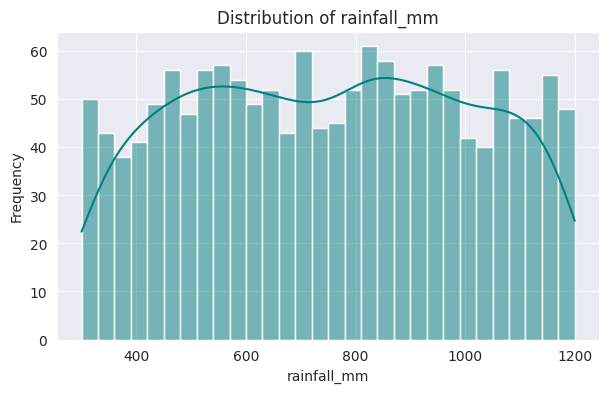

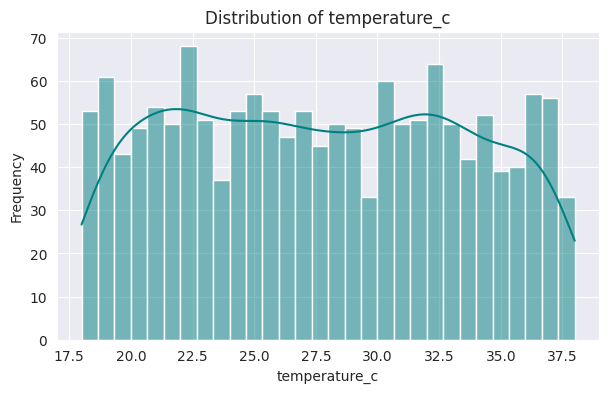

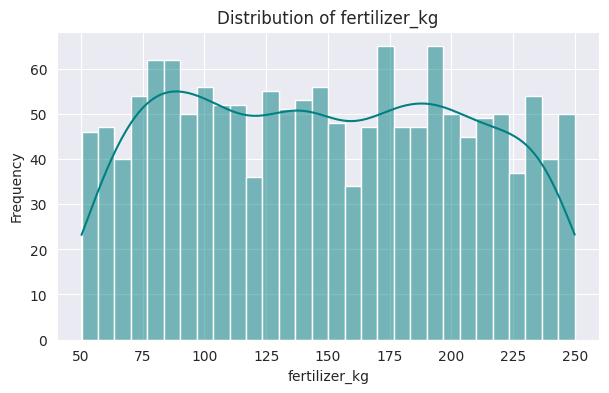

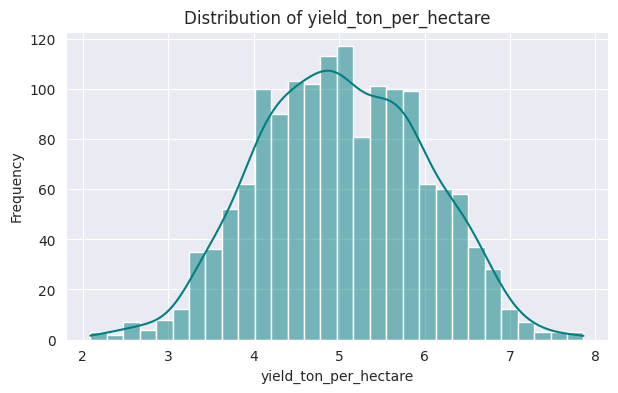

In [6]:
cols_to_plot = ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'yield_ton_per_hectare']

for col in cols_to_plot:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True, bins=30, color='teal')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


/tmp/ipykernel_4355/108916903.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='crop_type', order=crop_counts.index, palette='viridis')


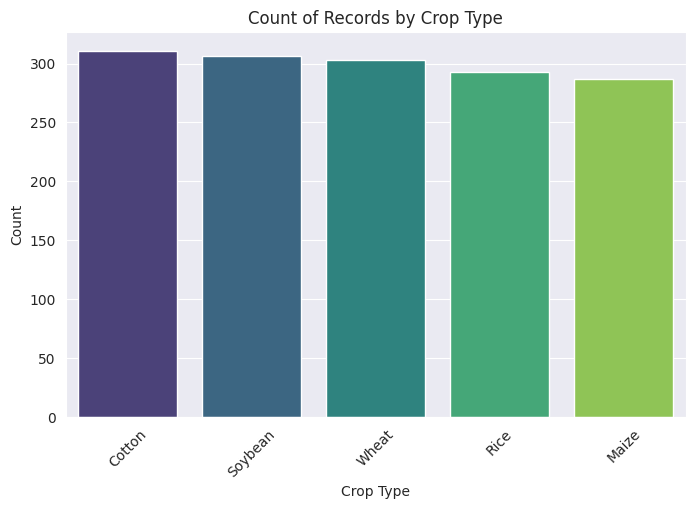


Most frequent crop type: Cotton


In [7]:
crop_counts = df['crop_type'].value_counts()
print(crop_counts)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='crop_type', order=crop_counts.index, palette='viridis')
plt.title('Count of Records by Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

print("\nMost frequent crop type:", crop_counts.idxmax())

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


/tmp/ipykernel_4355/211857256.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='soil_type', order=soil_counts.index, palette='magma')


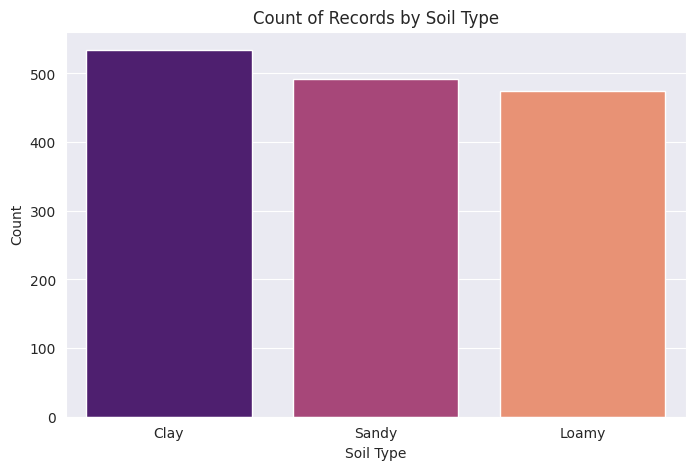


Most common soil type: Clay


In [8]:
soil_counts = df['soil_type'].value_counts()
print(soil_counts)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='soil_type', order=soil_counts.index, palette='magma')
plt.title('Count of Records by Soil Type')
plt.xlabel('Soil Type')
plt.ylabel('Count')
plt.show()

print("\nMost common soil type:", soil_counts.idxmax())

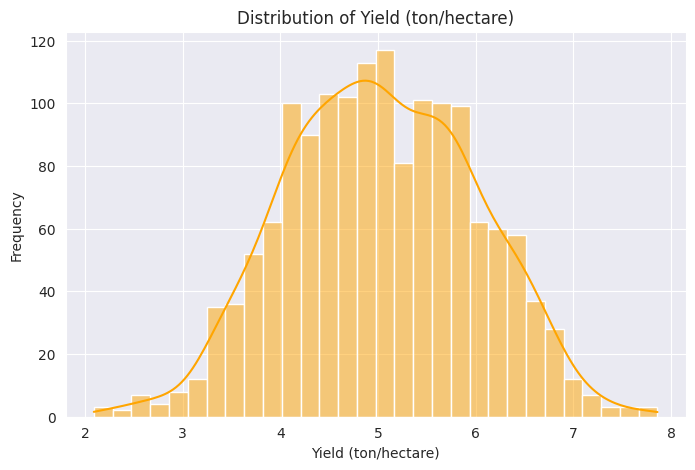

Skewness: -0.001169711222739871
Number of outliers detected: 3


In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['yield_ton_per_hectare'], kde=True, bins=30, color='orange')
plt.title('Distribution of Yield (ton/hectare)')
plt.xlabel('Yield (ton/hectare)')
plt.ylabel('Frequency')
plt.show()

print("Skewness:", df['yield_ton_per_hectare'].skew())

# Outlier check using IQR method
Q1 = df['yield_ton_per_hectare'].quantile(0.25)
Q3 = df['yield_ton_per_hectare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['yield_ton_per_hectare'] < lower_bound) | (df['yield_ton_per_hectare'] > upper_bound)]
print(f"Number of outliers detected: {outliers.shape[0]}")

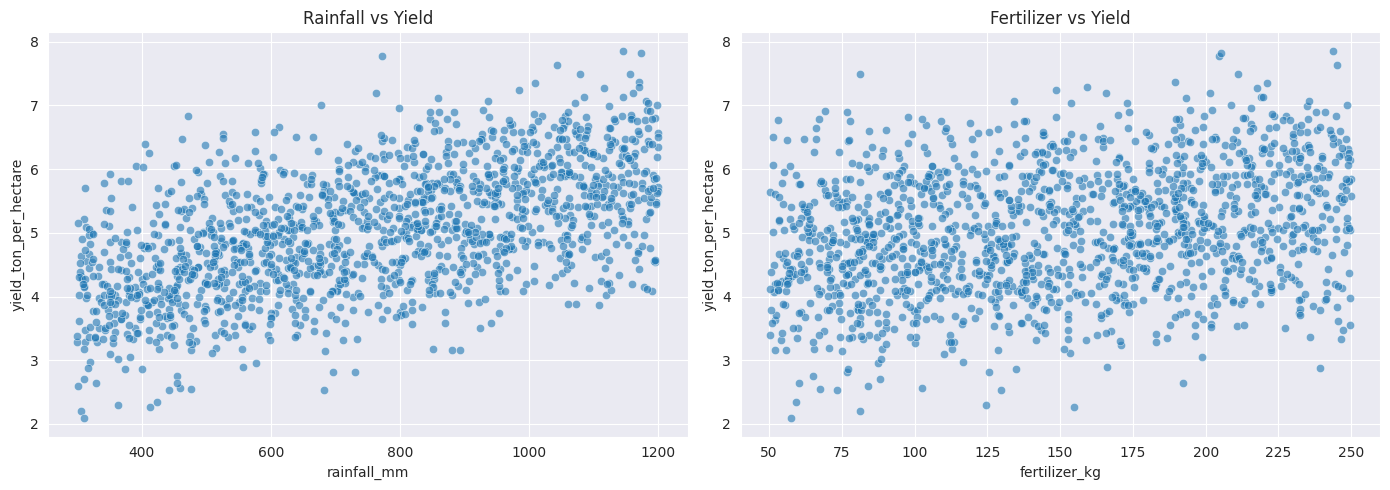

Correlation (rainfall vs yield): 0.5537042408932247
Correlation (fertilizer vs yield): 0.27804258886930494

Feature with stronger relationship to yield: rainfall_mm


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(data=df, x='rainfall_mm', y='yield_ton_per_hectare', alpha=0.6, ax=axes[0])
axes[0].set_title('Rainfall vs Yield')

sns.scatterplot(data=df, x='fertilizer_kg', y='yield_ton_per_hectare', alpha=0.6, ax=axes[1])
axes[1].set_title('Fertilizer vs Yield')

plt.tight_layout()
plt.show()

corr_rainfall = df['rainfall_mm'].corr(df['yield_ton_per_hectare'])
corr_fertilizer = df['fertilizer_kg'].corr(df['yield_ton_per_hectare'])
print("Correlation (rainfall vs yield):", corr_rainfall)
print("Correlation (fertilizer vs yield):", corr_fertilizer)

stronger = 'rainfall_mm' if abs(corr_rainfall) > abs(corr_fertilizer) else 'fertilizer_kg'
print(f"\nFeature with stronger relationship to yield: {stronger}")

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

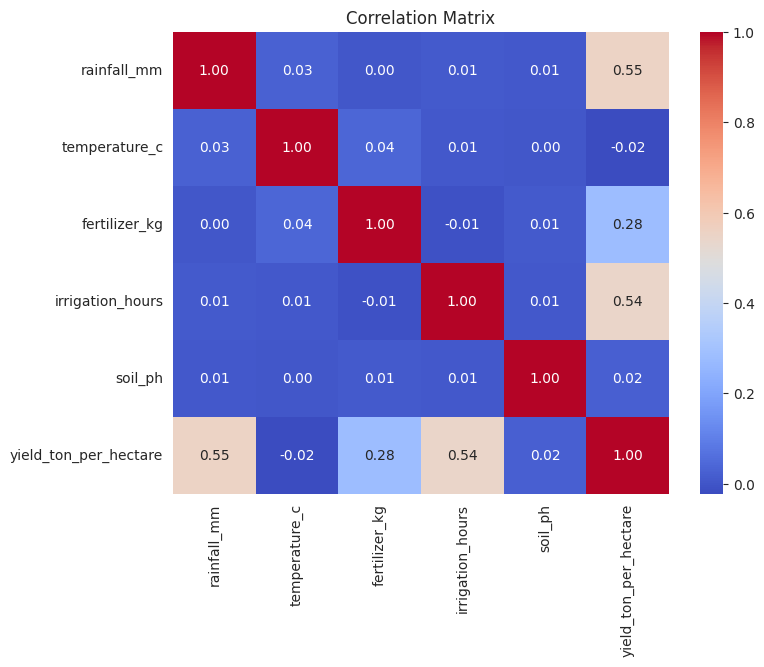


Top 3 features most correlated with yield:
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


In [11]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Top 3 features most correlated with yield (excluding yield itself)
top_corr = corr_matrix['yield_ton_per_hectare'].drop('yield_ton_per_hectare').abs().sort_values(ascending=False)
print("\nTop 3 features most correlated with yield:")
print(top_corr.head(3))

In [12]:
avg_yield_crop = df.groupby('crop_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
print("Average yield by crop type:\n", avg_yield_crop)

avg_yield_soil = df.groupby('soil_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
print("\nAverage yield by soil type:\n", avg_yield_soil)

print("\nCrop type with highest average yield:", avg_yield_crop.idxmax())
print("Soil type with highest average yield:", avg_yield_soil.idxmax())

Average yield by crop type:
 crop_type
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Maize      4.897143
Cotton     4.607299
Name: yield_ton_per_hectare, dtype: float64

Average yield by soil type:
 soil_type
Loamy    5.366519
Clay     5.134326
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Crop type with highest average yield: Rice
Soil type with highest average yield: Loamy


In [13]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("\nFirst five rows of the transformed dataset:")
df_encoded.head()

Categorical columns: ['crop_type', 'soil_type']

First five rows of the transformed dataset:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


In [14]:
X = df_encoded.drop('yield_ton_per_hectare', axis=1)
y = df_encoded['yield_ton_per_hectare']

print("Target variable: yield_ton_per_hectare")
print("\nInput features (X) shape:", X.shape)
print("Target variable (y) shape:", y.shape)
print("\nInput feature columns:", X.columns.tolist())

Target variable: yield_ton_per_hectare

Input features (X) shape: (1500, 11)
Target variable (y) shape: (1500,)

Input feature columns: ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type_Maize', 'crop_type_Rice', 'crop_type_Soybean', 'crop_type_Wheat', 'soil_type_Loamy', 'soil_type_Sandy']


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1200, 11)
X_test shape: (300, 11)
y_train shape: (1200,)
y_test shape: (300,)


In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Intercept:", model.intercept_)
print("\nModel Coefficients:")
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coef_df)

print("\nFeature with highest positive coefficient:", coef_df.iloc[0]['Feature'])

Model Intercept: 1.587132027736121

Model Coefficients:
              Feature  Coefficient
6      crop_type_Rice     0.863993
7   crop_type_Soybean     0.481719
8     crop_type_Wheat     0.348474
9     soil_type_Loamy     0.302974
5     crop_type_Maize     0.238931
3    irrigation_hours     0.198327
2       fertilizer_kg     0.004978
4             soil_ph     0.004901
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
10    soil_type_Sandy    -0.490933

Feature with highest positive coefficient: crop_type_Rice


# New Section